<a href="https://colab.research.google.com/github/Lucasgomesbit/engenharia_de_prompt_e_aplicacoes/blob/main/ProgramacaoAssistidaPorAI_aula07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Aula 07 _ miniprojeto

Nome: Lucas Gomes
Disciplina: Engenharia de Prompt e Aplicação em IA

In [ ]:
#Soma de LISTA
numeros = [1, 2, 3, 4, 5, 6]
soma = sum(numeros)
print(soma)

21


In [ ]:
soma = sum(numeros)
print(soma)

21


In [ ]:
# NUMERO PRIMO
import math

def eh_primo(n):
  if n < 2:
    return False
  if n == 2:
    return True
  if n % 2 == 0:
    return False
  for i in range(3, int(math.sqrt(n)) + 1, 2):
    if n % i == 0:
      return False
  return True

# ELABORE O TESTE
print(f"1 é primo? {eh_primo(1)}") # Esperado: False
print(f"2 é primo? {eh_primo(2)}") # Esperado: True
print(f"3 é primo? {eh_primo(3)}") # Esperado: True
print(f"4 é primo? {eh_primo(4)}") # Esperado: False
print(f"5 é primo? {eh_primo(5)}") # Esperado: True
print(f"7 é primo? {eh_primo(7)}") # Esperado: True
print(f"10 é primo? {eh_primo(10)}") # Esperado: False
print(f"11 é primo? {eh_primo(11)}") # Esperado: True
print(f"13 é primo? {eh_primo(13)}") # Esperado: True
print(f"17 é primo? {eh_primo(17)}") # Esperado: True
print(f"20 é primo? {eh_primo(20)}") # Esperado: False
print(f"23 é primo? {eh_primo(23)}") # Esperado: True
print(f"29 é primo? {eh_primo(29)}") # Esperado: True

1 é primo? False
2 é primo? True
3 é primo? True
4 é primo? False
5 é primo? True
7 é primo? True
10 é primo? False
11 é primo? True
13 é primo? True
17 é primo? True
20 é primo? False
23 é primo? True
29 é primo? True


In [ ]:
# INVERSÃO DE STRING

def inverte_texto(texto):
  invertido = ''
  for letra in texto:
    invertido = letra + invertido
  return invertido

# Exemplo de uso:
minha_string = 'Lucas'
string_invertida = inverte_texto(minha_string)
print(string_invertida)


sacuL


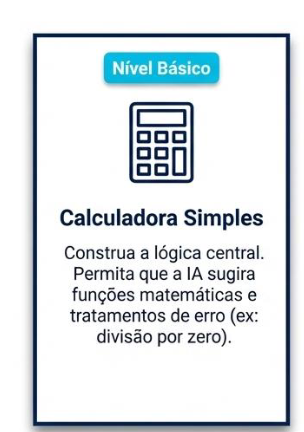

In [ ]:
num1 = float(input('Digite um número:'))
num2 = float(input('Digite um número:'))

operacoes = input('Escolha qual operação deseja fazer:, (+, -, /, *)')

if operacoes == '+':
    resultado = num1 + num2
    print('O resultado da soma é:', resultado)
elif operacoes == '-':
    resultado = num1 - num2
    print('O resultado da subtração é:', resultado)
elif operacoes == '/':
    if num2 == 0:
        print('Erro: Não é possível dividir por zero!')
    else:
        resultado = num1 / num2
        print('O resultado da divisão é:', resultado)
elif operacoes == '*':
    resultado = num1 * num2
    print('O resultado da multiplicação é:', resultado)
else:
    print('Refaça a operação!')

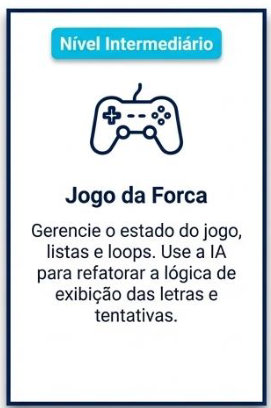

In [ ]:
import random
from os import system, name

def limpa_tela():
    if name == 'nt':
        _ = system('cls')
    else:
        _ = system('clear')

def game():
    limpa_tela()
    print('\nBem-vindo(a) ao jogo da forca!')
    print('Adivinhe a palavra abaixo:\n')

    palavras = ['cruzeiro', 'flamengo', 'barcelona', 'internacional', 'goias', 'manchester city']
    palavra = random.choice(palavras)
    letras_descobertas = ['_' if letra != ' ' else ' ' for letra in palavra]  # preserva espaços

    chances = 6
    letras_erradas = []

    while chances > 0:
        print('\n' + ' '.join(letras_descobertas))
        print(f'Chances restantes: {chances}')
        print('Letras erradas:', ' '.join(letras_erradas))

        tentativa = input('\nDigite uma letra: ').lower()

        if tentativa in palavra:
            for index, letra in enumerate(palavra):
                if tentativa == letra:
                    letras_descobertas[index] = letra
        else:
            if tentativa not in letras_erradas:
                chances -= 1
                letras_erradas.append(tentativa)

        if '_' not in letras_descobertas:
            print('\nVocê venceu! A palavra era:', palavra)
            break
    else:
        print('\nVocê perdeu! A palavra era:', palavra)

# Chama o jogo
game()

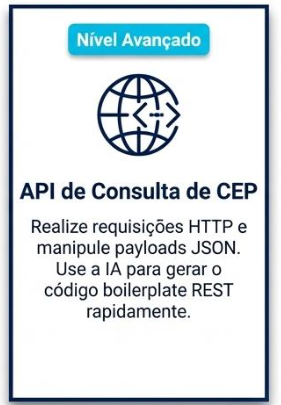


In [ ]:
import requests
import json

def consultar_cep(cep):
    """
    Consulta um CEP utilizando a API ViaCEP.
    Retorna os dados do endereço em formato JSON.
    """
    # A API ViaCEP geralmente não precisa de autenticação para consultas simples.
    # Formato da URL da API ViaCEP:
    url = f"https://viacep.com.br/ws/{cep}/json/"

    try:
        # Faz a requisição HTTP GET para a API
        response = requests.get(url)
        response.raise_for_status()  # Levanta um HTTPError para respostas de erro (4xx ou 5xx)

        # Tenta decodificar a resposta JSON
        data = response.json()

        # ViaCEP retorna um dicionário com uma chave 'erro' se o CEP for inválido
        if 'erro' in data and data['erro']:
            print(f"Erro: CEP {cep} não encontrado ou inválido.")
            return None
        else:
            return data

    except requests.exceptions.HTTPError as http_err:
        print(f"Erro HTTP: {http_err} - Status Code: {response.status_code}")
        return None
    except requests.exceptions.ConnectionError as conn_err:
        print(f"Erro de Conexão: {conn_err}")
        return None
    except requests.exceptions.Timeout as timeout_err:
        print(f"Erro de Timeout: {timeout_err}")
        return None
    except requests.exceptions.RequestException as req_err:
        print(f"Erro inesperado na requisição: {req_err}")
        return None
    except json.JSONDecodeError:
        print("Erro ao decodificar a resposta JSON.")
        print(f"Resposta da API (texto): {response.text}")
        return None

# --- Exemplo de uso ---

# Consulta um CEP válido
cep_valido = "01001000"  # São Paulo, SP
dados_cep = consultar_cep(cep_valido)

if dados_cep:
    print(f"\nDados do CEP {cep_valido}:")
    print(json.dumps(dados_cep, indent=4, ensure_ascii=False)) # Imprime JSON formatado
    print(f"Endereço: {dados_cep.get('logradouro')}, {dados_cep.get('bairro')} - {dados_cep.get('localidade')}/{dados_cep.get('uf')}")

# Consulta um CEP inválido
cep_invalido = "99999999"
dados_cep_invalido = consultar_cep(cep_invalido)

if not dados_cep_invalido:
    print(f"\nComo esperado, nenhum dado retornado para o CEP inválido {cep_invalido}.")


# --- Boilerplate REST Client (mais genérico) ---

class RESTClient:
    def __init__(self, base_url):
        self.base_url = base_url

    def _make_request(self, method, endpoint, params=None, data=None, json_data=None, headers=None):
        url = f"{self.base_url}/{endpoint}"
        try:
            response = requests.request(method, url, params=params, data=data, json=json_data, headers=headers)
            response.raise_for_status() # Raise HTTPError for bad responses (4xx or 5xx)
            return response.json() # Assume JSON response
        except requests.exceptions.HTTPError as http_err:
            print(f"HTTP error occurred: {http_err} - {response.status_code} - {response.text}")
        except requests.exceptions.ConnectionError as conn_err:
            print(f"Connection error occurred: {conn_err}")
        except requests.exceptions.Timeout as timeout_err:
            print(f"Timeout error occurred: {timeout_err}")
        except requests.exceptions.RequestException as e:
            print(f"An unexpected error occurred: {e}")
        except json.JSONDecodeError:
            print(f"Failed to decode JSON from response: {response.text}")
        return None

    def get(self, endpoint, params=None, headers=None):
        return self._make_request('GET', endpoint, params=params, headers=headers)

    def post(self, endpoint, data=None, json_data=None, headers=None):
        return self._make_request('POST', endpoint, data=data, json_data=json_data, headers=headers)

    def put(self, endpoint, data=None, json_data=None, headers=None):
        return self._make_request('PUT', endpoint, data=data, json_data=json_data, headers=headers)

    def delete(self, endpoint, headers=None):
        return self._make_request('DELETE', endpoint, headers=headers)

# --- Exemplo de uso do cliente REST genérico com ViaCEP ---
print("\n--- Exemplo de uso do cliente REST genérico com ViaCEP ---")
cep_api_base_url = "https://viacep.com.br/ws"
cep_client = RESTClient(cep_api_base_url)

# Endpoint para consulta de CEP é "{cep}/json/"
# Vamos consultar o mesmo CEP válido
cep_para_cliente = "01001000"
endpoint = f"{cep_para_cliente}/json/"
dados_via_cliente = cep_client.get(endpoint)

if dados_via_cliente:
    print(f"\nDados do CEP {cep_para_cliente} (via RESTClient genérico):")
    print(json.dumps(dados_via_cliente, indent=4, ensure_ascii=False))
else:
    print(f"Falha ao obter dados para o CEP {cep_para_cliente} via RESTClient genérico.")


